In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

print('✓ Libraries loaded')

✓ Libraries loaded


In [20]:

FILE_PATH = '../data/daily_gross_amount_and_members.csv'

df = pd.read_csv(FILE_PATH)
df['date'] = pd.to_datetime(df['date'])
df['gross_amount'] = pd.to_numeric(df['gross_amount'], errors='coerce').fillna(0)

df['month'] = df['date'].dt.to_period('M')
monthly = df.groupby('month')['gross_amount'].sum().reset_index()
monthly.columns = ['ds', 'y']
monthly['ds'] = monthly['ds'].dt.to_timestamp()
monthly = monthly[monthly['y'] > 0].sort_values('ds').reset_index(drop=True)

print(f'✓ Data loaded')
print(f'   Total months: {len(monthly)}')
print(f'   Date range: {monthly["ds"].min().strftime("%b %Y")} → {monthly["ds"].max().strftime("%b %Y")}')
print(f'   Total revenue: PKR {monthly["y"].sum():,.0f}')
print()
print(monthly.to_string(index=False))

✓ Data loaded
   Total months: 47
   Date range: Apr 2021 → Jan 2026
   Total revenue: PKR 128,135,570

        ds           y
2021-04-01      700.00
2022-04-01    71350.00
2022-05-01     7725.00
2022-06-01  2439850.00
2022-07-01   237700.00
2022-08-01   717600.00
2022-09-01  1647400.00
2022-10-01   312150.00
2022-11-01   918600.00
2022-12-01   846900.00
2023-01-01   909600.00
2023-02-01  4117600.00
2023-03-01  1095750.00
2023-04-01    58100.00
2023-05-01   929050.00
2023-06-01  1739150.00
2023-07-01   154900.00
2023-08-01  1108900.00
2023-09-01  2225300.00
2023-10-01   297750.00
2023-11-01    48150.00
2023-12-01  1025450.00
2024-01-01  2430750.00
2024-02-01 14368270.00
2024-03-01  3145920.00
2024-04-01  1593470.00
2024-05-01  2095860.00
2024-06-01  2560935.00
2024-07-01  1911460.00
2024-08-01  1678120.00
2024-09-01  2525530.00
2024-10-01  1871520.00
2024-11-01  6063980.00
2024-12-01  5437793.50
2025-01-01  7293635.00
2025-02-01  3296750.00
2025-03-01  3264535.00
2025-04-01  2732335.00

In [ ]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(monthly['ds'], monthly['y'], color='#3b82f6', alpha=0.8, width=20)
ax.set_title('Historical Monthly Revenue', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (PKR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()
print('✓ Historical data plotted')

In [ ]:


TEST_MONTHS = 6

train = monthly.iloc[:-TEST_MONTHS].copy()
test  = monthly.iloc[-TEST_MONTHS:].copy()

print(f'✓ Split complete')
print(f'   TRAIN: {train["ds"].min().strftime("%b %Y")} → {train["ds"].max().strftime("%b %Y")} ({len(train)} months)')
print(f'   TEST:  {test["ds"].min().strftime("%b %Y")}  → {test["ds"].max().strftime("%b %Y")}  ({len(test)} months)')
print()
print('Test months (actual values — model will NOT see these):')
for _, row in test.iterrows():
    print(f'   {row["ds"].strftime("%Y-%m")}: PKR {row["y"]:>15,.0f}')

In [7]:
print('Training Prophet model on historical data...')
print('(This may take 30-60 seconds)')
print()

train['_m'] = train['ds'].dt.month
monthly_avg = train.groupby('_m')['y'].mean()
global_avg  = monthly_avg.mean()
peak_months = monthly_avg[monthly_avg > global_avg * 1.3].index.tolist()

MN = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(f'Peak months detected from data: {[MN[m-1] for m in peak_months]}')

years = list(range(2021, 2027))
hrows = []
for m in peak_months:
    for yr in years:
        try:
            start = pd.Timestamp(f'{yr}-{m:02d}-01')
            for d in pd.date_range(start=start, periods=30, freq='D'):
                hrows.append({'holiday': f'{MN[m-1]}_peak', 'ds': d,
                              'lower_window': -2, 'upper_window': 3})
        except:
            pass

hdf = pd.DataFrame(hrows) if hrows else None

model = Prophet(
    holidays=hdf,
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.1,
    interval_width=0.80
)

model.fit(train[['ds', 'y']])
print('✓ Model trained successfully')

Training Prophet model on historical data...
(This may take 30-60 seconds)

Peak months detected from data: ['Jan', 'Feb']


14:16:32 - cmdstanpy - INFO - Chain [1] start processing
14:16:33 - cmdstanpy - INFO - Chain [1] done processing


✓ Model trained successfully


In [8]:
future   = model.make_future_dataframe(periods=TEST_MONTHS, freq='MS')
forecast = model.predict(future)

test_fc = forecast[forecast['ds'].isin(test['ds'])][['ds','yhat','yhat_lower','yhat_upper']].copy()
test_fc['yhat']       = test_fc['yhat'].clip(lower=0).round()
test_fc['yhat_lower'] = test_fc['yhat_lower'].clip(lower=0).round()
test_fc['yhat_upper'] = test_fc['yhat_upper'].clip(lower=0).round()

results = test.merge(test_fc, on='ds')
results.columns = ['Month', 'Actual', 'Forecast', 'Low', 'High']

print('✓ Predictions complete')
print()
print(f'{"Month":<10} {"Actual":>15} {"Forecast":>15} {"Error":>10} {"Accuracy":>10}')
print('-' * 65)
for _, r in results.iterrows():
    err = r['Forecast'] - r['Actual']
    acc = max(0, 100 - abs(err) / r['Actual'] * 100) if r['Actual'] > 0 else 0
    print(f'{r["Month"].strftime("%Y-%m"):<10} {r["Actual"]:>15,.0f} {r["Forecast"]:>15,.0f} {err:>+10,.0f} {acc:>9.1f}%')

✓ Predictions complete

Month               Actual        Forecast      Error   Accuracy
-----------------------------------------------------------------
2025-08          2,584,266       2,528,973    -55,293      97.9%
2025-09          3,666,840       4,281,949   +615,109      83.2%
2025-10          2,531,405       2,009,533   -521,872      79.4%
2025-11          9,727,586       5,633,223 -4,094,363      57.9%
2025-12          6,373,957       5,435,798   -938,159      85.3%
2026-01         10,180,163       8,305,151 -1,875,012      81.6%


In [22]:
# Step 7 — Accuracy metrics
results['error']    = results['Forecast'] - results['Actual']
results['abs_err']  = results['error'].abs()
results['acc']      = results.apply(
    lambda r: max(0, 100 - r['abs_err'] / r['Actual'] * 100) if r['Actual'] > 0 else 0, axis=1
)

mape = (results['abs_err'] / results['Actual'] * 100).mean()
avg_acc = results['acc'].mean()

rmse = np.sqrt((results['error'] ** 2).mean())

print('=' * 50)
print('         BASELINE ACCURACY RESULTS')
print('=' * 50)
print(f'  Average Accuracy : {avg_acc:.1f}%')
print(f'  MAPE             : {mape:.1f}%')
print(f'  RMSE             : PKR {rmse:,.0f}')
print('=' * 50)

if avg_acc >= 80:
    print(f'  ✅ GOOD — Model is reliable ({avg_acc:.1f}% accurate)')
    print('     Ready for production tool.')
elif avg_acc >= 60:
    print(f'  ⚠️  MODERATE — Model needs improvement ({avg_acc:.1f}%)')
    print('     More data or tuning needed.')
else:
    print(f'  ❌ LOW — Model not reliable yet ({avg_acc:.1f}%)')
    print('     Data quality or quantity issue.')
print('=' * 50)

         BASELINE ACCURACY RESULTS
  Average Accuracy : 80.9%
  MAPE             : 19.1%
  RMSE             : PKR 1,906,716
  ✅ GOOD — Model is reliable (80.9% accurate)
     Ready for production tool.


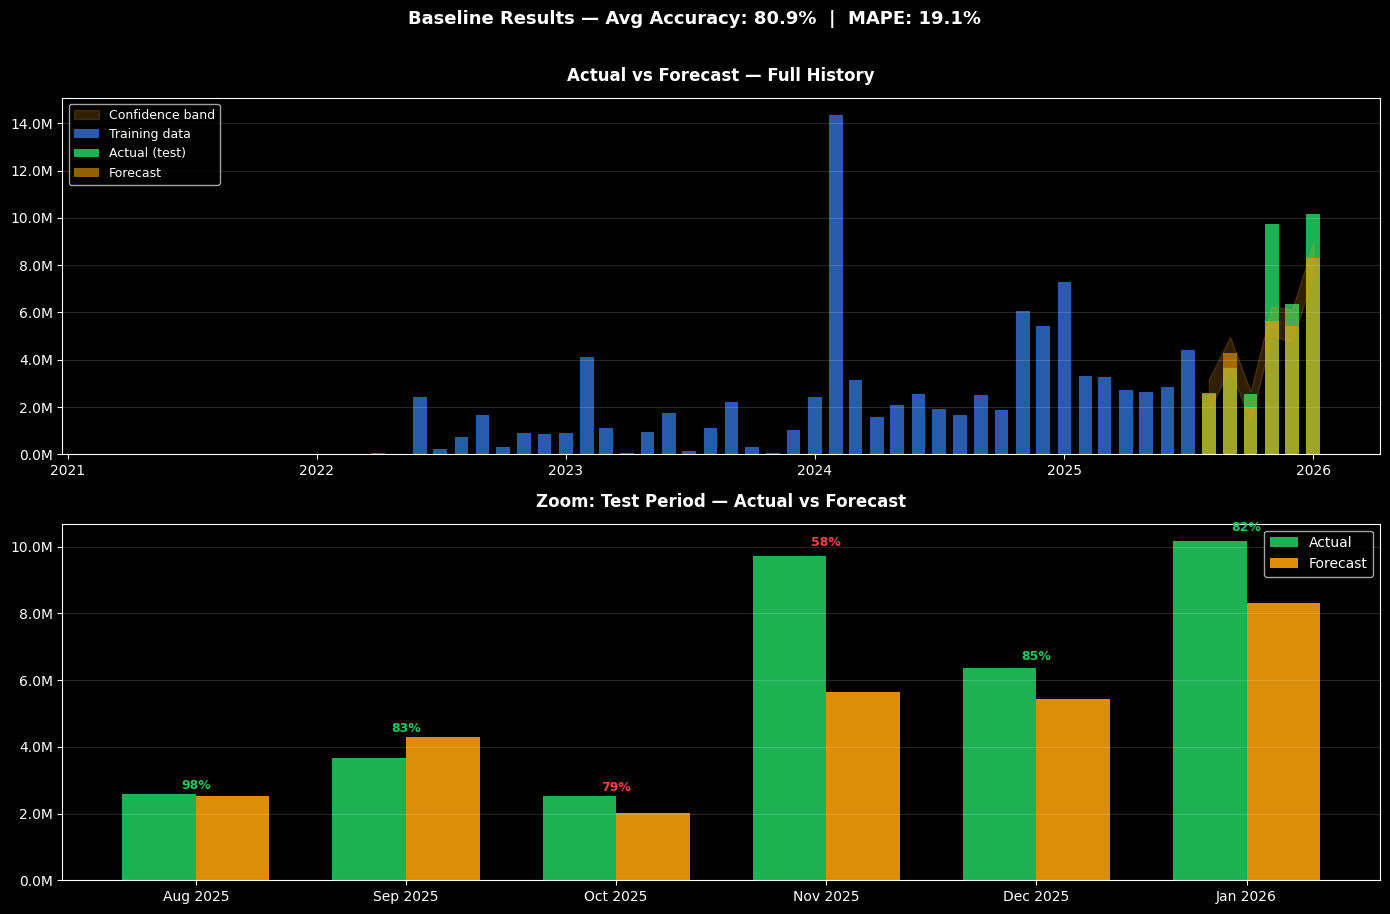

✓ Chart saved as baseline_results.png


In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

ax1 = axes[0]
ax1.bar(train['ds'], train['y'], color='#3b82f6', alpha=0.7, width=20, label='Training data')
ax1.bar(results['Month'], results['Actual'], color='#22c55e', alpha=0.9, width=20, label='Actual (test)')
ax1.bar(results['Month'], results['Forecast'], color='#f59e0b', alpha=0.6, width=20, label='Forecast')
ax1.fill_between(results['Month'], results['Low'], results['High'],
                  alpha=0.2, color='#f59e0b', label='Confidence band')
ax1.set_title('Actual vs Forecast — Full History', fontsize=12, fontweight='bold', pad=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(axis='y', alpha=0.15)

ax2 = axes[1]
x = np.arange(len(results))
w = 0.35
bars1 = ax2.bar(x - w/2, results['Actual'],   width=w, color='#22c55e', alpha=0.9, label='Actual')
bars2 = ax2.bar(x + w/2, results['Forecast'], width=w, color='#f59e0b', alpha=0.9, label='Forecast')
ax2.set_xticks(x)
ax2.set_xticklabels([m.strftime('%b %Y') for m in results['Month']])
ax2.set_title('Zoom: Test Period — Actual vs Forecast', fontsize=12, fontweight='bold', pad=12)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

for i, (_, r) in enumerate(results.iterrows()):
    ax2.text(i, max(r['Actual'], r['Forecast']) * 1.02,
             f'{r["acc"]:.0f}%', ha='center', va='bottom', fontsize=9,
             color='#22c55e' if r['acc'] >= 80 else '#ef4444', fontweight='bold')

ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.15)

plt.suptitle(f'Baseline Results — Avg Accuracy: {avg_acc:.1f}%  |  MAPE: {mape:.1f}%',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('baseline_results.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print('✓ Chart saved as baseline_results.png')

In [11]:
print()
print('SUMMARY')
print('─' * 50)
print(f'Data used       : {len(train)} months training, {len(test)} months test')
print(f'Model           : Prophet (Meta AI)')
print(f'Peak months     : {[MN[m-1] for m in peak_months]}')
print(f'Average accuracy: {avg_acc:.1f}%')
print(f'MAPE            : {mape:.1f}%')
print()
print('Month-wise breakdown:')
for _, r in results.iterrows():
    bar = '█' * int(r['acc'] / 5)
    print(f"  {r['Month'].strftime('%b %Y')}  {bar:<20} {r['acc']:.1f}%")
print()
if avg_acc >= 80:
    print('✅ Baseline proven — tool is ready to build.')
else:
    print('⚠️  Accuracy low — check data quality or add more months.')


SUMMARY
──────────────────────────────────────────────────
Data used       : 41 months training, 6 months test
Model           : Prophet (Meta AI)
Peak months     : ['Jan', 'Feb']
Average accuracy: 80.9%
MAPE            : 19.1%

Month-wise breakdown:
  Aug 2025  ███████████████████  97.9%
  Sep 2025  ████████████████     83.2%
  Oct 2025  ███████████████      79.4%
  Nov 2025  ███████████          57.9%
  Dec 2025  █████████████████    85.3%
  Jan 2026  ████████████████     81.6%

✅ Baseline proven — tool is ready to build.
